# Phase 3: Epipolar Constrained MatchFormer Inference
This notebook dynamically modifies MatchFormer's cross-attention forward pass so that it is explicitly masked by the Fundamental Matrix epipolar lines.

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

from config.defaultmf import get_cfg_defaults
from model.lightning_loftr import PL_LoFTR
from match_poses import read_trajectory, get_pose_for_image
from gt_epipolar import compute_fundamental_matrix, K
from compute_ear import compute_EAR, random_baseline_EAR

print("Imports successful.")


Imports successful.


/Users/siddharthraj/classes/cv/final-proj/env/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Epipolar Mask Generator
This function creates a soft distance penalty mask. Values on the epipolar line are 1.0, decaying exponentially as you move away.

In [2]:
def create_epipolar_mask(F, H_feat, W_feat, query_pt, H_img=480, W_img=640, tau=10.0):
    """
    F: 3x3 Fundamental Matrix
    H_feat, W_feat: Resolution of the attention feature map
    query_pt: (x, y) coordinates of the query in the source image
    tau: Temperature controlling the mask decay (higher = wider line)
    """
    p = np.array([query_pt[0], query_pt[1], 1.0])
    l_prime = F @ p 
    a, b, c = l_prime
    
    # Create coordinate grid at feature map resolution
    y_feat, x_feat = np.mgrid[0:H_feat, 0:W_feat]
    
    # Scale feature coordinates back to image pixel coordinates
    x_img = (x_feat / W_feat) * W_img
    y_img = (y_feat / H_feat) * H_img
    
    # Calculate geometric distance from every point to the line
    distances = np.abs(a*x_img + b*y_img + c) / np.sqrt(a**2 + b**2)
    
    # Soft exponential decay mask (1.0 on line, approaches 0 further away)
    mask = np.exp(-distances / tau)
    
    # Reshape to (1, N) where N = H_feat * W_feat
    mask_flat = mask.flatten()
    return torch.from_numpy(mask_flat).float()


## Monkey Patching `Attention.forward()`
We override the forward method to accept our Epipolar Mask and multiply it against the Attention probabilities right before Z-normalization.

In [3]:
config = get_cfg_defaults()
config.MATCHFORMER.BACKBONE_TYPE = 'litela'
config.MATCHFORMER.SCENS = 'indoor'
config.MATCHFORMER.RESOLUTION = (8, 4)
config.MATCHFORMER.COARSE.D_MODEL = 192
config.MATCHFORMER.COARSE.D_FFN = 192

model = PL_LoFTR(config, pretrained_ckpt='model/weights/indoor-lite-LA.ckpt')
model.eval()

# We only want to hook Stage 4 for this visualization
HW_layer_map = {'stage4_cross': (15, 20)}
cross_attn_matrices = {}

def get_constrained_cross_attn(name, layer, ux, uy, F_matrix):
    def hook(model, input, output):
        x = input[0]
        B, N, C = x.shape
        MiniB = B // 2
        
        query = layer.q(x).reshape(B, N, layer.num_heads, C // layer.num_heads).permute(0, 1, 2, 3)
        kv = layer.kv(x).reshape(B, -1, 2, layer.num_heads, C // layer.num_heads).permute(2, 0, 1, 3, 4)
        
        if layer.cross:
            k1, k2 = kv[0].split(MiniB)
            key = torch.cat([k2, k1], dim=0) 
        else:
            return 
            
        Q = layer.feature_map(query).permute(0, 2, 1, 3) 
        K = layer.feature_map(key).permute(0, 2, 1, 3)
        
        H_feat, W_feat = HW_layer_map[name]
        feat_x = int((ux / 640.0) * W_feat)
        feat_y = int((uy / 480.0) * H_feat)
        query_idx = feat_y * W_feat + feat_x

        Q_single = Q[0, :, query_idx:query_idx+1, :] 
        K_targets = K[0, :, :, :]
        
        # 1. Standard Dot Product (Unnormalized)
        attn = torch.matmul(Q_single, K_targets.transpose(-2, -1)) # Shape: (num_heads, 1, N)
        
        # 2. INJECT EPIPOLAR MASK!
        epipolar_mask = create_epipolar_mask(F_matrix, H_feat, W_feat, (ux, uy)) # Shape: (N,)
        epipolar_mask = epipolar_mask.view(1, 1, -1).to(attn.device) # Broadcast to (1, 1, N)
        
        # Apply mask (forces elements far from epipolar line towards 0)
        attn_masked = attn * epipolar_mask
        
        # 3. Re-Normalized Masked Attention (Z factor)
        # Summing the *masked* attention ensures probabilities still sum to 1.0!
        Z = 1 / (attn_masked.sum(dim=-1, keepdim=True) + layer.eps)
        attn_final = attn_masked * Z
        
        cross_attn_matrices[name] = attn_final.mean(dim=0).squeeze(0).detach().cpu()
        
    return hook

print("Patch functions defined.")


2026-03-12 15:52:11.104 | INFO     | model.lightning_loftr:__init__:34 - Load 'model/weights/indoor-lite-LA.ckpt' as pretrained checkpoint


Patch functions defined.


In [4]:
def get_image(path, resize=(640, 480)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, resize)
    img = cv2.resize(img, resize)
    img_tensor = torch.from_numpy(img).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)
    return img_rgb, img_tensor

gt_file = '../tum_rgb_dataset/groundtruth.txt'
poses = read_trajectory(gt_file)
rgb_dir = '../tum_rgb_dataset/rgb/*.png'
all_imgs = sorted(glob.glob(rgb_dir))

def run_constrained_inference(img1_idx, img2_idx, query_points):
    img1_path = all_imgs[img1_idx]
    img2_path = all_imgs[img2_idx]
    
    img1_rgb, img1_tensor = get_image(img1_path)
    img2_rgb, img2_tensor = get_image(img2_path)
    
    T1 = get_pose_for_image(img1_path, poses)
    T2 = get_pose_for_image(img2_path, poses)
    if T1 is None or T2 is None: return
    F = compute_fundamental_matrix(T1, T2, K, K)
    
    input_data = {'image0': img1_tensor, 'image1': img2_tensor}
    
    for (pt_name, (ux, uy)) in query_points.items():
        cross_attn_matrices.clear()
        
        # Register our specifically constrained hook
        h = model.matcher.backbone.AttentionBlock4.block[2].attn.register_forward_hook(
            get_constrained_cross_attn('stage4_cross', model.matcher.backbone.AttentionBlock4.block[2].attn, ux, uy, F)
        )
        
        with torch.no_grad():
            model.matcher(input_data)
        h.remove()
        
        # Math for visuals
        p = np.array([ux, uy, 1.0])
        l_prime = F @ p 
        a, b, c = l_prime
        
        attn_map = cross_attn_matrices['stage4_cross']
        H_feat, W_feat = HW_layer_map['stage4_cross']
        attn_heatmap = attn_map.reshape(H_feat, W_feat).numpy()
        attn_resized = cv2.resize(attn_heatmap, (640, 480))
        
        # Calculate new EAR
        attn_prob = attn_resized / np.sum(attn_resized)
        ear_val = compute_EAR(attn_prob, a, b, c, 10)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].imshow(img1_rgb)
        axes[0].plot(ux, uy, 'r*', markersize=15, label='Query')
        axes[0].set_title(f"Source: {pt_name}")
        axes[0].axis('off')
        
        attn_norm = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min() + 1e-8)
        axes[1].imshow(img2_rgb)
        axes[1].imshow(attn_norm, cmap='jet', alpha=0.5)
        
        x0, x1 = 0, 640
        y0 = int(-(a*x0 + c) / b)
        y1 = int(-(a*x1 + c) / b)
        axes[1].plot([x0, x1], [y0, y1], 'w--', linewidth=2, label='Epipolar Line')
        
        axes[1].set_xlim([0, 640])
        axes[1].set_ylim([480, 0])
        axes[1].axis('off')
        axes[1].set_title(f"CONSTRAINED Stage 4 Attention\nEAR: {ear_val:.4f}")
        plt.tight_layout()
        plt.show()


## Evaluate Ambiguous Points with Constrained Forward Pass
Notice how the Blank Wall point now adheres heavily to the physical Epipolar geometry constraint rather than predicting noise.

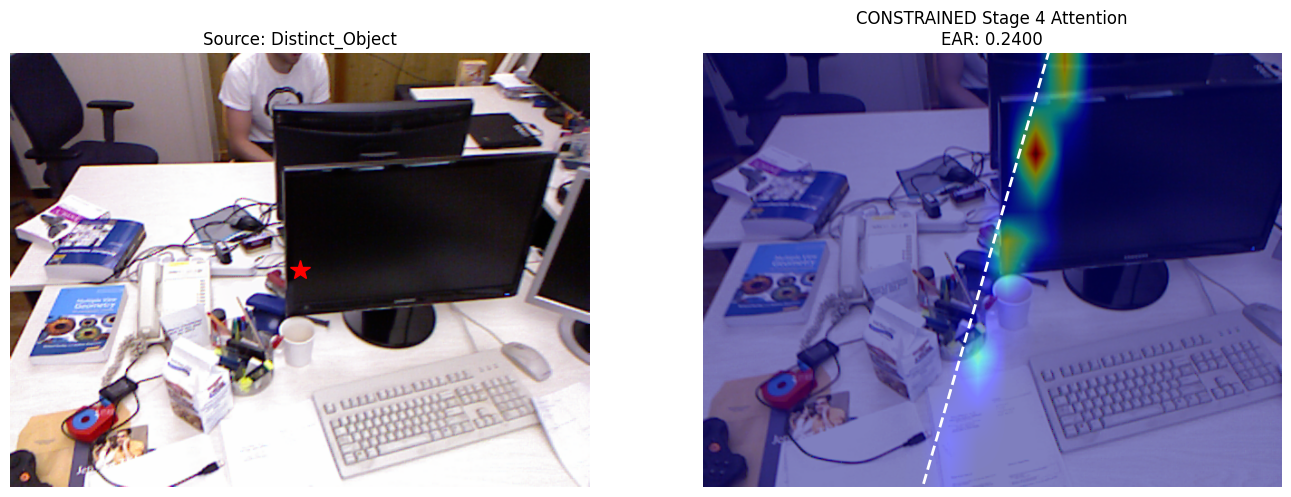

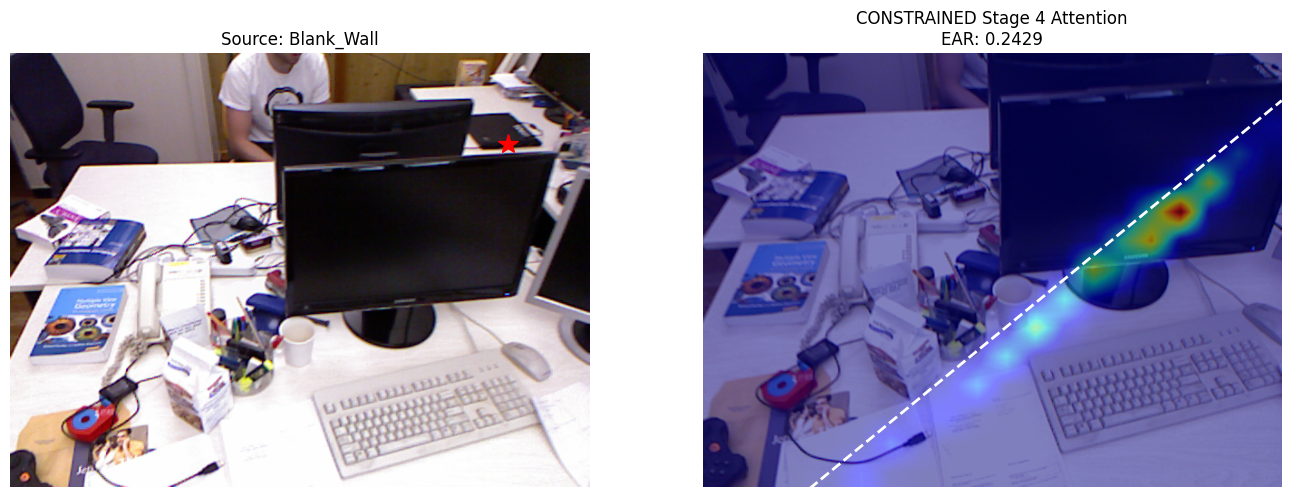

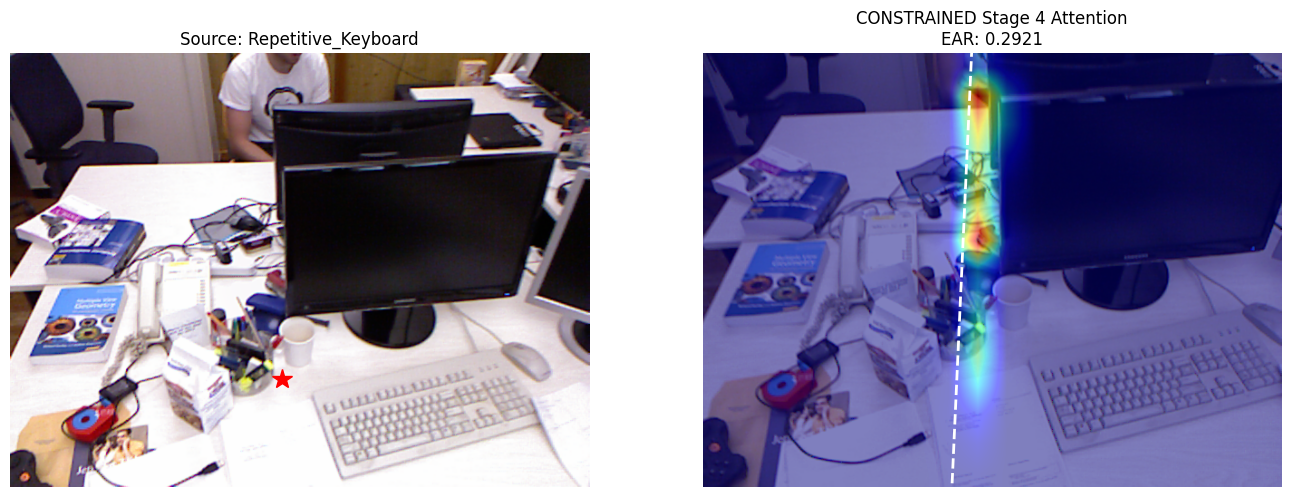

In [5]:
test_points = {
    'Distinct_Object': (320, 240),      # Center, busy texture area
    'Blank_Wall': (550, 100),           # Top right empty wall corner
    'Repetitive_Keyboard': (300, 360)   # On the keyboard keys
}

run_constrained_inference(0, 10, test_points)
